# Questão 3 — LoRA e QLoRA (experimento independente)

**Ponto de partida:** `gpt2-large` pré-treinado bruto do HuggingFace — o mesmo para SFT (Q2), LoRA e QLoRA.

| Variante | Base | Pesos W | Params treináveis |
|---|---|---|---|
| Baseline | gpt2-large virgem | float16 | — (sem treino) |
| SFT completo (Q2) | gpt2-large virgem | float16 | 774 M |
| **LoRA** | gpt2-large virgem | float16 (congelado) | ~800 k |
| **QLoRA** | gpt2-large virgem | NF4 4-bit (congelado) | ~800 k |

O baseline é medido **uma única vez** sobre o modelo virgem e serve de referência para todos.
Os resultados do SFT completo (Q2) são carregados do `sft_model/metrics.json` para a comparação final.

## 0. Instalação

In [1]:
!uv add peft bitsandbytes accelerate transformers torch matplotlib tqdm

Resolved 175 packages in 2ms
Audited 155 packages in 10ms


## 1. Imports e hiperparâmetros

In [2]:
import json, math, time
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, GPT2LMHeadModel,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
)
from peft import (
    LoraConfig, get_peft_model, TaskType,
    PeftModel, prepare_model_for_kbit_training,
)
from tqdm.auto import tqdm

SEED = 13
torch.manual_seed(SEED)

# ── Caminhos ──────────────────────────────────────────────────────────────────
ARTIFACTS_DIR = Path("sft_artifacts")       # tokenizer + dataset preparados na Q1
SFT_METRICS   = Path("sft_model/metrics.json")  # métricas do SFT completo (Q2)
LORA_OUT      = Path("lora_model");  LORA_OUT.mkdir(exist_ok=True)
QLORA_OUT     = Path("qlora_model"); QLORA_OUT.mkdir(exist_ok=True)

# ── Modelo base — SEMPRE o pré-treinado bruto ─────────────────────────────────
PRETRAINED_MODEL = "gpt2-large"   # mesmo ponto de partida do SFT (Q2)

# ── LoRA ──────────────────────────────────────────────────────────────────────
LORA_R              = 16
LORA_ALPHA          = 32      # escala = alpha/r = 2  (convenção)
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = ["c_attn", "c_proj", "mlp.c_fc", "mlp.c_proj"]

# ── Treino ────────────────────────────────────────────────────────────────────
NUM_EPOCHS       = 3      # LoRA converge mais lentamente que SFT completo
BATCH_SIZE       = 8      # LoRA libera VRAM suficiente para batch maior
GRAD_ACCUM_STEPS = 1      # batch efetivo = 8
LEARNING_RATE    = 2e-4   # LR maior é padrão para LoRA
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.06
MAX_GRAD_NORM    = 1.0
EVAL_EVERY       = 40
PAD_TOKEN_ID     = 50256
IGNORE_INDEX     = -100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

c:\Users\raffa\Documents\UFPI\Tópicos em IA\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## 2. Dataset e DataLoaders

In [3]:
ckpt       = torch.load(ARTIFACTS_DIR / "processed_dataset.pt", map_location="cpu")
train_data = ckpt["train"]
val_data   = ckpt["val"]
test_data  = ckpt["test"]

# Tokenizer com tokens especiais Phi-3 (salvo na Q1)
tokenizer = AutoTokenizer.from_pretrained(ARTIFACTS_DIR / "tokenizer")
tokenizer.pad_token_id = PAD_TOKEN_ID
USER_TOKEN      = "<|user|>"
ASSISTANT_TOKEN = "<|assistant|>"

print(f"Dataset : train={len(train_data)} | val={len(val_data)} | test={len(test_data)}")
print(f"Vocab   : {len(tokenizer)} tokens")

class InstructionDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        s = self.data[i]
        return {k: s[k] for k in ("input_ids", "target_ids", "attention_mask")}

def collate_fn(batch):
    """Padding dinâmico ao comprimento máximo real do batch."""
    max_len = max(s["attention_mask"].sum().item() for s in batch)
    iids, tids, masks = [], [], []
    for s in batch:
        r = s["attention_mask"].sum().item(); p = max_len - r
        iids.append( torch.cat([s["input_ids"][:r],      torch.full((p,), PAD_TOKEN_ID, dtype=torch.long)]))
        tids.append( torch.cat([s["target_ids"][:r],     torch.full((p,), IGNORE_INDEX,  dtype=torch.long)]))
        masks.append(torch.cat([s["attention_mask"][:r], torch.zeros(p,   dtype=torch.long)]))
    return {"input_ids": torch.stack(iids),
            "target_ids": torch.stack(tids),
            "attention_mask": torch.stack(masks)}

pin = DEVICE.type == "cuda"
train_loader = DataLoader(InstructionDataset(train_data), BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, pin_memory=pin)
val_loader   = DataLoader(InstructionDataset(val_data),   BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, pin_memory=pin)
test_loader  = DataLoader(InstructionDataset(test_data),  BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, pin_memory=pin)
print(f"Loaders : {len(train_loader)} train | {len(val_loader)} val | {len(test_loader)} test")

Dataset : train=850 | val=100 | test=50
Vocab   : 50259 tokens
Loaders : 107 train | 13 val | 7 test


## 3. Funções compartilhadas (loss, avaliação, geração, loop de treino)

In [5]:
def compute_loss(model, batch, use_fp16=True):
    iids  = batch["input_ids"].to(DEVICE)
    tids  = batch["target_ids"].to(DEVICE)
    amask = batch["attention_mask"].to(DEVICE)
    ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))
    with ctx:
        logits = model(input_ids=iids, attention_mask=amask).logits
        return nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)(
            logits.view(-1, logits.size(-1)), tids.view(-1))


@torch.no_grad()
def evaluate(model, loader, use_fp16=True):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        total += compute_loss(model, batch, use_fp16).item(); n += 1
    model.train()
    avg = total / n
    return avg, math.exp(avg)


@torch.no_grad()
def generate_response(model, instruction, inp="",
                      max_new_tokens=200, temp=0.7, top_p=0.9):
    user = instruction + (f"\n{inp}" if inp else "")
    prompt = f"{USER_TOKEN}\n{user}\n{ASSISTANT_TOKEN}\n"
    ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    model.eval()
    out = model.generate(
        ids, max_new_tokens=max_new_tokens,
        temperature=temp, top_p=top_p, do_sample=True,
        pad_token_id=PAD_TOKEN_ID, eos_token_id=PAD_TOKEN_ID)
    text = tokenizer.decode(out[0, ids.shape[1]:], skip_special_tokens=True)
    for stop in [USER_TOKEN, ASSISTANT_TOKEN, "<|endoftext|>"]:
        if stop in text: text = text[:text.index(stop)]
    model.train()
    return text.strip()


def train_loop(model, tag, out_dir, use_fp16=True):
    """
    Loop genérico reutilizado por LoRA e QLoRA.
    Salva o melhor adapter (PEFT) em out_dir/best_adapter/.
    Salva o histórico incremental em out_dir/history.json a cada eval.
    Retorna dicionário de histórico para plotagem.
    """
    total_steps  = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    trainable    = [p for p in model.parameters() if p.requires_grad]

    optimizer = torch.optim.AdamW(trainable, lr=LEARNING_RATE,
                                   weight_decay=WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, warmup_steps, total_steps)
    scaler = torch.cuda.amp.GradScaler(
        enabled=(use_fp16 and DEVICE.type == "cuda"))

    hist = {"train_loss": [], "val_loss": [], "val_ppl": [],
            "steps": [], "tokens": []}
    best_val, tokens_seen, step = float("inf"), 0, 0
    t0 = time.time()

    # Avaliação inicial (antes de qualquer atualização)
    init_val, init_ppl = evaluate(model, val_loader, use_fp16)
    print(f"[{tag}] baseline val_loss={init_val:.4f}  ppl={init_ppl:.2f}")
    hist["init_val_loss"] = init_val
    hist["init_val_ppl"]  = init_ppl

    model.train(); optimizer.zero_grad()

    for epoch in range(1, NUM_EPOCHS + 1):
        ep_loss, ep_n = 0.0, 0
        pbar = tqdm(train_loader, desc=f"[{tag}] época {epoch}/{NUM_EPOCHS}")

        for i, batch in enumerate(pbar, 1):
            loss = compute_loss(model, batch, use_fp16) / GRAD_ACCUM_STEPS
            scaler.scale(loss).backward()
            tokens_seen += batch["attention_mask"].sum().item()
            ep_loss += loss.item() * GRAD_ACCUM_STEPS; ep_n += 1

            if i % GRAD_ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(trainable, MAX_GRAD_NORM)
                scaler.step(optimizer); scaler.update()
                scheduler.step(); optimizer.zero_grad()
                step += 1
                pbar.set_postfix({"loss": f"{loss.item()*GRAD_ACCUM_STEPS:.4f}",
                                   "tok":  f"{tokens_seen//1000}k"})

                if step % EVAL_EVERY == 0:
                    vl, vp = evaluate(model, val_loader, use_fp16)
                    hist["train_loss"].append(ep_loss / ep_n)
                    hist["val_loss"].append(vl)
                    hist["val_ppl"].append(vp)
                    hist["steps"].append(step)
                    hist["tokens"].append(tokens_seen)
                    # Persiste histórico incremental — recuperável sem reprocessar
                    (out_dir / "history.json").write_text(
                        json.dumps(hist, ensure_ascii=False, indent=2))
                    tqdm.write(f"  step {step:4d} | train={ep_loss/ep_n:.4f} "
                               f"val={vl:.4f} ppl={vp:.2f}")
                    if vl < best_val:
                        best_val = vl
                        model.save_pretrained(out_dir / "best_adapter")
                        tokenizer.save_pretrained(out_dir / "best_adapter")
                        tqdm.write(f"  checkpoint salvo (val={vl:.4f})")

        vl, vp = evaluate(model, val_loader, use_fp16)
        print(f"  época {epoch} | val={vl:.4f} ppl={vp:.2f} "
              f"tempo={(time.time()-t0)/60:.1f} min")

    hist["best_val_loss"]     = best_val
    hist["total_min"]         = (time.time() - t0) / 60
    hist["trainable_params"]  = sum(p.numel() for p in trainable)
    # Salva histórico final completo
    (out_dir / "history.json").write_text(
        json.dumps(hist, ensure_ascii=False, indent=2))
    return hist


# Perguntas de avaliação qualitativa (fixas para comparação justa)
TEST_QUESTIONS = [
    "O que é uma árvore AVL e quais são suas propriedades de balanceamento?",
    "Explique o algoritmo QuickSort e sua complexidade no melhor e pior caso.",
    "Qual a diferença entre processos e threads em sistemas operacionais?",
    "O que é normalização em banco de dados? Explique 1FN, 2FN e 3FN.",
    "Como funciona o protocolo TCP e o que é o three-way handshake?",
]

print("Funções auxiliares prontas.")
print(f"Carregando {PRETRAINED_MODEL} (baseline)...")
baseline_model = GPT2LMHeadModel.from_pretrained(
    PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)

# Redimensiona embeddings para os tokens especiais Phi-3
old_vocab = baseline_model.config.vocab_size
new_vocab  = len(tokenizer)
if new_vocab != old_vocab:
    baseline_model.resize_token_embeddings(new_vocab)
    with torch.no_grad():
        mean_emb = baseline_model.transformer.wte.weight[:old_vocab].mean(0)
        baseline_model.transformer.wte.weight[old_vocab:] = mean_emb
    print(f"  embedding: {old_vocab} → {new_vocab}")

# Métricas do baseline
baseline_val_loss, baseline_val_ppl = evaluate(baseline_model, val_loader)
baseline_test_loss, baseline_test_ppl = evaluate(baseline_model, test_loader)
print(f"\nBaseline — val_loss={baseline_val_loss:.4f} | val_ppl={baseline_val_ppl:.2f}")
print(f"Baseline — test_loss={baseline_test_loss:.4f} | test_ppl={baseline_test_ppl:.2f}")

# Respostas do modelo virgem
print("\nRespostas do modelo base (sem treino):")
baseline_responses = {}
for q in TEST_QUESTIONS:
    r = generate_response(baseline_model, q)
    baseline_responses[q] = r
    print(f"\nQ: {q}")
    print(f"A: {r[:250]}{'...' if len(r)>250 else ''}")

# Persiste métricas e respostas do baseline para recuperação sem re-inferência
Path("baseline_metrics.json").write_text(json.dumps({
    "val_loss":  round(baseline_val_loss,  4),
    "val_ppl":   round(baseline_val_ppl,   2),
    "test_loss": round(baseline_test_loss, 4),
    "test_ppl":  round(baseline_test_ppl,  2),
    "responses": baseline_responses,
}, ensure_ascii=False, indent=2))
print("\nBaseline salvo em baseline_metrics.json")

# Libera memória antes do LoRA
del baseline_model
torch.cuda.empty_cache()
print("Modelo baseline liberado da VRAM.")

Funções auxiliares prontas.
Carregando gpt2-large (baseline)...


Loading weights: 100%|██████████| 436/436 [00:02<00:00, 166.67it/s]
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  embedding: 50257 → 50259


C:\Users\raffa\AppData\Local\Temp\ipykernel_28804\3196504183.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Baseline — val_loss=3.4478 | val_ppl=31.43
Baseline — test_loss=3.5938 | test_ppl=36.37

Respostas do modelo base (sem treino):

Q: O que é uma árvore AVL e quais são suas propriedades de balanceamento?
A: Feminist

"The real problem is that women are not equal. I'm not saying that women aren't capable of being good feminists, but they are not equal to men in terms of their own worth and worth as human beings. Women are still viewed as sexual objects, ...

Q: Explique o algoritmo QuickSort e sua complexidade no melhor e pior caso.
A: "I'll tell you something. If you want to know more about the world, you should visit the museums. But you can't stay in the same place for too long. You have to leave. There are many places where you can go."
"Museums?"
"Yes. In the city."
"What do t...

Q: Qual a diferença entre processos e threads em sistemas operacionais?
A: Sempre de comunicación de aplicar el programa.
Nunca mejor más de cómo viven a diferençar al programa.
Cómo me diferenció a tener

## 4. Baseline — gpt2-large pré-treinado bruto

Carregado **sem qualquer fine-tuning**. Este é o ponto de comparação compartilhado
pelos três experimentos (SFT da Q2, LoRA e QLoRA).

In [6]:
print(f"Carregando {PRETRAINED_MODEL} (baseline)...")
baseline_model = GPT2LMHeadModel.from_pretrained(
    PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)

# Redimensiona embeddings para os tokens especiais Phi-3
old_vocab = baseline_model.config.vocab_size
new_vocab  = len(tokenizer)
if new_vocab != old_vocab:
    baseline_model.resize_token_embeddings(new_vocab)
    with torch.no_grad():
        mean_emb = baseline_model.transformer.wte.weight[:old_vocab].mean(0)
        baseline_model.transformer.wte.weight[old_vocab:] = mean_emb
    print(f"  embedding: {old_vocab} → {new_vocab}")

# Métricas do baseline
baseline_val_loss, baseline_val_ppl = evaluate(baseline_model, val_loader)
baseline_test_loss, baseline_test_ppl = evaluate(baseline_model, test_loader)
print(f"\nBaseline — val_loss={baseline_val_loss:.4f} | val_ppl={baseline_val_ppl:.2f}")
print(f"Baseline — test_loss={baseline_test_loss:.4f} | test_ppl={baseline_test_ppl:.2f}")

# Respostas do modelo virgem
print("\nRespostas do modelo base (sem treino):")
baseline_responses = {}
for q in TEST_QUESTIONS:
    r = generate_response(baseline_model, q)
    baseline_responses[q] = r
    print(f"\nQ: {q}")
    print(f"A: {r[:250]}{'...' if len(r)>250 else ''}")

# Persiste métricas e respostas do baseline para recuperação sem re-inferência
Path("baseline_metrics.json").write_text(json.dumps({
    "val_loss":  round(baseline_val_loss,  4),
    "val_ppl":   round(baseline_val_ppl,   2),
    "test_loss": round(baseline_test_loss, 4),
    "test_ppl":  round(baseline_test_ppl,  2),
    "responses": baseline_responses,
}, ensure_ascii=False, indent=2))
print("\nBaseline salvo em baseline_metrics.json")

# Libera memória antes do LoRA
del baseline_model
torch.cuda.empty_cache()
print("Modelo baseline liberado da VRAM.")

Carregando gpt2-large (baseline)...


Loading weights: 100%|██████████| 436/436 [00:00<00:00, 1029.08it/s]


  embedding: 50257 → 50259


C:\Users\raffa\AppData\Local\Temp\ipykernel_28804\3196504183.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))



Baseline — val_loss=3.4478 | val_ppl=31.43
Baseline — test_loss=3.5938 | test_ppl=36.37

Respostas do modelo base (sem treino):

Q: O que é uma árvore AVL e quais são suas propriedades de balanceamento?
A: Árvore se ha está o uma uma árvore AVL e quais são suas propriedades de balanceamento?

Por o que é uma árvore AVL e quais são suas propriedades de balanceamento?

Por o que é uma árvore AVL e quais são suas propriedades de balanceamento?

Por o que ...

Q: Explique o algoritmo QuickSort e sua complexidade no melhor e pior caso.
A: (I am the most sophisticated person in the world)
Eu la forma não se encontração e dois como seu não seu fica.
(I can't count my money in one day)
Eu puedo lugar ou como seu fica.
(I can't count my money in one day)
Eu puedo lugar ou como seu fica.
(...

Q: Qual a diferença entre processos e threads em sistemas operacionais?
A: Não são trabalho, a qualquer que não próprio.
Etter eu a não próprio que os processos do corrupção a oportunidade
Diferente não p

## 4.5. SFT

Carrega o `gpt-large` pós-treinado com SFT (questão 2)

In [7]:
SFT_MODEL_DIR = Path("sft_model/hf_model")

print(f"Carregando modelo SFT de {SFT_MODEL_DIR}...")
sft_model = GPT2LMHeadModel.from_pretrained(
    SFT_MODEL_DIR, torch_dtype=torch.float16
).to(DEVICE)

if len(tokenizer) != sft_model.config.vocab_size:
    old_vocab = sft_model.config.vocab_size
    sft_model.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        mean_emb = sft_model.transformer.wte.weight[:old_vocab].mean(0)
        sft_model.transformer.wte.weight[old_vocab:] = mean_emb
    print(f"  embedding: {old_vocab} → {len(tokenizer)}")

sft_responses = []
print("\nRespostas do modelo SFT (Q2):")
for q in TEST_QUESTIONS:
    r = generate_response(sft_model, q)
    sft_responses.append({"question": q, "after": r})
    print(f"\nQ: {q}")
    print(f"A: {r[:250]}{'...' if len(r) > 250 else ''}")
    
# save SFT responses to a JSON file for later comparison separando em "question" e "after":
with open("sft_model/qualitative_comparison.json", "w", encoding="utf-8") as f:
    json.dump(sft_responses, f, ensure_ascii=False, indent=4)

Carregando modelo SFT de sft_model\hf_model...


Loading weights: 100%|██████████| 436/436 [00:01<00:00, 330.81it/s]



Respostas do modelo SFT (Q2):

Q: O que é uma árvore AVL e quais são suas propriedades de balanceamento?
A: Uma árvore AVL é um tipo de árvore balanceamento usado para garantir que o usuário não gera um tempo de busca, inserção e exclusão. Ela mantém a propriedade de balanceamento dos elementos em que a altura de altura é calculada ao longo do tempo. Isso ...

Q: Explique o algoritmo QuickSort e sua complexidade no melhor e pior caso.
A: QuickSort é uma sequência finita de partes do código, usada para sortar uma estrutura de dados em ordem. Ele divide a lista de valores em uma lista de bits, e fornece a eficiência da superfície de ordenação. Por exemplo, um lista de bits tem menor ma...

Q: Qual a diferença entre processos e threads em sistemas operacionais?
A: Threads são operações de processamento que permitem a manipulação de sistemas operacionais em um ambiente real. Em sistemas operacionais, elas têm um processo de execução (que a execução executa) e têm um processo de execução (

## 5. LoRA — pesos W congelados em float16

Carrega `gpt2-large` pré-treinado bruto (não o SFT da Q2).
Congela todos os pesos e adiciona matrizes A e B de rank 16.

In [8]:
print(f"Carregando {PRETRAINED_MODEL} para LoRA...")
base_for_lora = GPT2LMHeadModel.from_pretrained(
    PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)

if len(tokenizer) != base_for_lora.config.vocab_size:
    base_for_lora.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        old_v = base_for_lora.config.vocab_size
        mean_emb = base_for_lora.transformer.wte.weight[:old_v].mean(0)
        base_for_lora.transformer.wte.weight[old_v:] = mean_emb

lora_cfg = LoraConfig(
    task_type      = TaskType.CAUSAL_LM,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = LORA_TARGET_MODULES,
    bias           = "none",
    inference_mode = False,
)
lora_model = get_peft_model(base_for_lora, lora_cfg)
lora_model.print_trainable_parameters()

torch.cuda.empty_cache()
print(f"VRAM alocada: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Carregando gpt2-large para LoRA...


Loading weights: 100%|██████████| 436/436 [00:01<00:00, 364.92it/s]
W0628 16:15:53.468000 28804 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
c:\Users\raffa\Documents\UFPI\Tópicos em IA\RAG\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 11,796,480 || all params: 785,829,120 || trainable%: 1.5012
VRAM alocada: 3.15 GB


In [ ]:
print("Iniciando treino LoRA...")
hist_lora = train_loop(lora_model, tag="LoRA", out_dir=LORA_OUT, use_fp16=True)
print(f"\nLoRA concluído em {hist_lora['total_min']:.1f} min")
print(f"  params treináveis : {hist_lora['trainable_params']:,}")
print(f"  best val_loss     : {hist_lora['best_val_loss']:.4f}")

Iniciando treino LoRA...


C:\Users\raffa\AppData\Local\Temp\ipykernel_30912\3015599248.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
C:\Users\raffa\AppData\Local\Temp\ipykernel_30912\3015599248.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))


[LoRA] baseline val_loss=3.4479  ppl=31.43


[LoRA] época 1/3:  36%|███▋      | 39/107 [12:28<19:49, 17.49s/it, loss=3.2629, tok=49k]

  step   40 | train=3.3803 val=2.9303 ppl=18.73


...

  step  320 | train=2.3944 val=2.3720 ppl=10.72


[LoRA] época 3/3:  99%|█████████▉| 106/107 [34:04<00:36, 36.08s/it, loss=2.2049, tok=395k]

  checkpoint salvo (val=2.3720)


[LoRA] época 3/3: 100%|██████████| 107/107 [34:05<00:00, 19.12s/it, loss=2.4141, tok=395k]


  época 3 | val=2.3719 ppl=10.72 tempo=103.7 min

LoRA concluído em 103.7 min
  params treináveis : 11,796,480
  best val_loss     : 2.3720


In [10]:
# Avaliação final LoRA — carrega melhor adapter sobre base virgem
base_reload_lora = GPT2LMHeadModel.from_pretrained(
    PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)
if len(tokenizer) != base_reload_lora.config.vocab_size:
    base_reload_lora.resize_token_embeddings(len(tokenizer))

lora_model_best = PeftModel.from_pretrained(
    base_reload_lora, LORA_OUT / "best_adapter")

lora_test_loss, lora_test_ppl = evaluate(lora_model_best, test_loader)
print(f"LoRA — test_loss={lora_test_loss:.4f} | test_ppl={lora_test_ppl:.2f}")

after_lora = {}
for q in TEST_QUESTIONS:
    after_lora[q] = generate_response(lora_model_best, q)

# Persiste métricas de avaliação e respostas qualitativas do LoRA
(LORA_OUT / "eval_metrics.json").write_text(json.dumps({
    "test_loss": round(lora_test_loss, 4),
    "test_ppl":  round(lora_test_ppl,  2),
    "responses": after_lora,
}, ensure_ascii=False, indent=2))
print("Métricas LoRA salvas em lora_model/eval_metrics.json")

del lora_model, lora_model_best, base_reload_lora
torch.cuda.empty_cache()
print("LoRA liberado da VRAM.")

Loading weights: 100%|██████████| 436/436 [00:01<00:00, 320.12it/s]
C:\Users\raffa\AppData\Local\Temp\ipykernel_28804\3196504183.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))


LoRA — test_loss=2.4218 | test_ppl=11.27
Métricas LoRA salvas em lora_model/eval_metrics.json
LoRA liberado da VRAM.


## 6. QLoRA — pesos W quantizados em NF4 4-bit

Carrega `gpt2-large` pré-treinado bruto com `BitsAndBytesConfig` (NF4).
Mesmos hiperparâmetros LoRA — a única diferença é o dtype de armazenamento de W.

In [11]:
if DEVICE.type != "cuda":
    raise RuntimeError("QLoRA exige GPU com CUDA.")

bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16,
    bnb_4bit_use_double_quant = True,
)

print(f"Carregando {PRETRAINED_MODEL} em NF4 para QLoRA...")
base_for_qlora = GPT2LMHeadModel.from_pretrained(
    PRETRAINED_MODEL,
    quantization_config = bnb_config,
    device_map          = "auto",
)

if len(tokenizer) != base_for_qlora.config.vocab_size:
    base_for_qlora.resize_token_embeddings(len(tokenizer))

# Prepara para treino kbit:
# - LayerNorm em float32 para estabilidade
# - gradient checkpointing ativo (troca tempo por VRAM)
base_for_qlora = prepare_model_for_kbit_training(
    base_for_qlora, use_gradient_checkpointing=True)

qlora_cfg = LoraConfig(
    task_type      = TaskType.CAUSAL_LM,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    target_modules = LORA_TARGET_MODULES,
    bias           = "none",
    inference_mode = False,
)
qlora_model = get_peft_model(base_for_qlora, qlora_cfg)
qlora_model.print_trainable_parameters()

torch.cuda.empty_cache()
print(f"VRAM alocada (QLoRA NF4): {torch.cuda.memory_allocated()/1e9:.2f} GB")

Carregando gpt2-large em NF4 para QLoRA...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]c:\Users\raffa\Documents\UFPI\Tópicos em IA\RAG\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 436/436 [00:01<00:00, 220.28it/s]


trainable params: 11,796,480 || all params: 785,829,120 || trainable%: 1.5012
VRAM alocada (QLoRA NF4): 3.84 GB


In [ ]:
print("Iniciando treino QLoRA...")
# use_fp16=False: bitsandbytes gerencia bfloat16 internamente;
# usar GradScaler de float16 por cima causaria conflito de precisão
hist_qlora = train_loop(
    qlora_model, tag="QLoRA", out_dir=QLORA_OUT, use_fp16=False)
print(f"\nQLoRA concluído em {hist_qlora['total_min']:.1f} min")
print(f"  params treináveis : {hist_qlora['trainable_params']:,}")
print(f"  best val_loss     : {hist_qlora['best_val_loss']:.4f}")

Iniciando treino QLoRA...


C:\Users\raffa\AppData\Local\Temp\ipykernel_30912\3015599248.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(
C:\Users\raffa\AppData\Local\Temp\ipykernel_30912\3015599248.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))


[QLoRA] baseline val_loss=3.4859  ppl=32.65


[QLoRA] época 1/3:   0%|          | 0/107 [00:00<?, ?it/s][transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
c:\Users\raffa\Documents\UFPI\Tópicos em IA\RAG\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
[QLoRA] época 1/3:  36%|███▋      | 39/107 [07:17<24:22, 21.50s/it, loss=2.9546, tok=49k]

  step   40 | train=3.4196 val=2.9574 ppl=19.25


...

  step  320 | train=2.4055 val=2.3866 ppl=10.88


[QLoRA] época 3/3:  99%|█████████▉| 106/107 [1:18:08<01:24, 85.00s/it, loss=2.2433, tok=395k]

  checkpoint salvo (val=2.3866)


[QLoRA] época 3/3: 100%|██████████| 107/107 [1:18:18<00:00, 43.91s/it, loss=2.5930, tok=395k]


  época 3 | val=2.3867 ppl=10.88 tempo=211.4 min

QLoRA concluído em 211.4 min
  params treináveis : 11,796,480
  best val_loss     : 2.3866


In [13]:
# Avaliação final QLoRA — carrega melhor adapter sobre base NF4 virgem
base_reload_q = GPT2LMHeadModel.from_pretrained(
    PRETRAINED_MODEL, quantization_config=bnb_config, device_map="auto")
if len(tokenizer) != base_reload_q.config.vocab_size:
    base_reload_q.resize_token_embeddings(len(tokenizer))
base_reload_q = prepare_model_for_kbit_training(base_reload_q)

qlora_model_best = PeftModel.from_pretrained(
    base_reload_q, QLORA_OUT / "best_adapter")

qlora_test_loss, qlora_test_ppl = evaluate(
    qlora_model_best, test_loader, use_fp16=False)
print(f"QLoRA — test_loss={qlora_test_loss:.4f} | test_ppl={qlora_test_ppl:.2f}")

after_qlora = {}
for q in TEST_QUESTIONS:
    after_qlora[q] = generate_response(qlora_model_best, q)

# Persiste métricas de avaliação e respostas qualitativas do QLoRA
(QLORA_OUT / "eval_metrics.json").write_text(json.dumps({
    "test_loss": round(qlora_test_loss, 4),
    "test_ppl":  round(qlora_test_ppl,  2),
    "responses": after_qlora,
}, ensure_ascii=False, indent=2))
print("Métricas QLoRA salvas em qlora_model/eval_metrics.json")

del qlora_model, qlora_model_best, base_reload_q
torch.cuda.empty_cache()
print("QLoRA liberado da VRAM.")

Loading weights: 100%|██████████| 436/436 [00:08<00:00, 51.61it/s]
C:\Users\raffa\AppData\Local\Temp\ipykernel_28804\3196504183.py:5: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  ctx   = torch.cuda.amp.autocast(enabled=(use_fp16 and DEVICE.type == "cuda"))


QLoRA — test_loss=2.4222 | test_ppl=11.27


c:\Users\raffa\Documents\UFPI\Tópicos em IA\RAG\.venv\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Métricas QLoRA salvas em qlora_model/eval_metrics.json
QLoRA liberado da VRAM.


## 7. Comparação quantitativa — baseline vs SFT vs LoRA vs QLoRA

In [25]:
# ── Recuperação de variáveis após reinício do kernel ──────────────────────────
# Carrega tudo do disco (artefatos gerados nas seções anteriores).
# Se as variáveis já existem na sessão atual, os blocos são pulados.

def _needs(var_name):
    return var_name not in globals()

# ── 1. Métricas SFT (JSON em disco) ──────────────────────────────────────────
if _needs("sft_metrics"):
    sft_metrics = json.loads(SFT_METRICS.read_text()) if SFT_METRICS.exists() else {}
    print("sft_metrics: carregado de", SFT_METRICS)

# ── 2. Baseline ───────────────────────────────────────────────────────────────
_baseline_file = Path("baseline_metrics.json")
if _needs("baseline_test_loss"):
    if _baseline_file.exists():
        _bd = json.loads(_baseline_file.read_text(encoding="utf-8"))
        baseline_val_loss  = _bd["val_loss"]
        baseline_val_ppl   = _bd["val_ppl"]
        baseline_test_loss = _bd["test_loss"]
        baseline_test_ppl  = _bd["test_ppl"]
        print(f"Baseline métricas: carregadas de {_baseline_file}")
    else:
        print("Carregando gpt2-large (baseline)...")
        _bm = GPT2LMHeadModel.from_pretrained(
            PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)
        _old_v = _bm.config.vocab_size
        if len(tokenizer) != _old_v:
            _bm.resize_token_embeddings(len(tokenizer))
            with torch.no_grad():
                _bm.transformer.wte.weight[_old_v:] = \
                    _bm.transformer.wte.weight[:_old_v].mean(0)
        baseline_val_loss,  baseline_val_ppl  = evaluate(_bm, val_loader)
        baseline_test_loss, baseline_test_ppl = evaluate(_bm, test_loader)
        if _needs("baseline_responses"):
            baseline_responses = {q: generate_response(_bm, q) for q in TEST_QUESTIONS}
        del _bm; torch.cuda.empty_cache()

if _needs("baseline_responses"):
    if _baseline_file.exists():
        baseline_responses = json.loads(
            _baseline_file.read_text(encoding="utf-8")).get("responses", {})
        print("  baseline_responses: carregadas de disco")
    else:
        print("AVISO: baseline_responses não encontrado — re-execute a célula 4.")
        baseline_responses = {}

# ── 3. hist_lora ──────────────────────────────────────────────────────────────
if _needs("hist_lora"):
    _lora_hist = LORA_OUT / "history.json"
    if _lora_hist.exists():
        hist_lora = json.loads(_lora_hist.read_text(encoding="utf-8"))
        print(f"hist_lora: carregado de {_lora_hist}  "
              f"({len(hist_lora['steps'])} checkpoints)")
    else:
        hist_lora = {
            "steps": [], "train_loss": [], "val_loss": [], "val_ppl": [],
            "tokens": [], "best_val_loss": None, "total_min": None,
            "trainable_params": None,
        }
        print("AVISO: hist_lora não encontrado — curvas de treino indisponíveis.")

# ── 4. LoRA eval (test_loss, test_ppl, respostas qualitativas) ────────────────
_lora_eval = LORA_OUT / "eval_metrics.json"
if _needs("lora_test_loss"):
    if _lora_eval.exists():
        _led = json.loads(_lora_eval.read_text(encoding="utf-8"))
        lora_test_loss = _led["test_loss"]
        lora_test_ppl  = _led["test_ppl"]
        print(f"LoRA eval: carregado de {_lora_eval}")
    else:
        print("Carregando adapter LoRA para avaliação...")
        _base = GPT2LMHeadModel.from_pretrained(
            PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)
        if len(tokenizer) != _base.config.vocab_size:
            _base.resize_token_embeddings(len(tokenizer))
        _lm = PeftModel.from_pretrained(_base, LORA_OUT / "best_adapter")
        lora_test_loss, lora_test_ppl = evaluate(_lm, test_loader)
        print(f"  LoRA test_loss={lora_test_loss:.4f}  ppl={lora_test_ppl:.2f}")
        if _needs("after_lora"):
            after_lora = {q: generate_response(_lm, q) for q in TEST_QUESTIONS}
        del _lm, _base; torch.cuda.empty_cache()

if _needs("after_lora"):
    if _lora_eval.exists():
        after_lora = json.loads(
            _lora_eval.read_text(encoding="utf-8")).get("responses", {})
        print("  after_lora: carregado de disco")
    else:
        print("AVISO: after_lora não encontrado — re-execute a célula 16.")
        after_lora = {}

# ── 5. hist_qlora ─────────────────────────────────────────────────────────────
if _needs("hist_qlora"):
    _qlora_hist = QLORA_OUT / "history.json"
    if _qlora_hist.exists():
        hist_qlora = json.loads(_qlora_hist.read_text(encoding="utf-8"))
        print(f"hist_qlora: carregado de {_qlora_hist}  "
              f"({len(hist_qlora['steps'])} checkpoints)")
    else:
        hist_qlora = {
            "steps": [], "train_loss": [], "val_loss": [], "val_ppl": [],
            "tokens": [], "best_val_loss": None, "total_min": None,
            "trainable_params": None,
        }
        print("AVISO: hist_qlora não encontrado — curvas de treino indisponíveis.")

# ── 6. QLoRA eval (test_loss, test_ppl, respostas qualitativas) ───────────────
_qlora_eval = QLORA_OUT / "eval_metrics.json"
if _needs("qlora_test_loss"):
    if _qlora_eval.exists():
        _qed = json.loads(_qlora_eval.read_text(encoding="utf-8"))
        qlora_test_loss = _qed["test_loss"]
        qlora_test_ppl  = _qed["test_ppl"]
        print(f"QLoRA eval: carregado de {_qlora_eval}")
    else:
        print("Carregando adapter QLoRA (NF4) para avaliação...")
        _bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
        _base_q = GPT2LMHeadModel.from_pretrained(
            PRETRAINED_MODEL, quantization_config=_bnb_cfg, device_map="auto")
        if len(tokenizer) != _base_q.config.vocab_size:
            _base_q.resize_token_embeddings(len(tokenizer))
        _base_q = prepare_model_for_kbit_training(_base_q)
        _qm = PeftModel.from_pretrained(_base_q, QLORA_OUT / "best_adapter")
        qlora_test_loss, qlora_test_ppl = evaluate(_qm, test_loader, use_fp16=False)
        print(f"  QLoRA test_loss={qlora_test_loss:.4f}  ppl={qlora_test_ppl:.2f}")
        if _needs("after_qlora"):
            after_qlora = {q: generate_response(_qm, q) for q in TEST_QUESTIONS}
        del _qm, _base_q; torch.cuda.empty_cache()

if _needs("after_qlora"):
    if _qlora_eval.exists():
        after_qlora = json.loads(
            _qlora_eval.read_text(encoding="utf-8")).get("responses", {})
        print("  after_qlora: carregado de disco")
    else:
        print("AVISO: after_qlora não encontrado — re-execute a célula 20.")
        after_qlora = {}

# ── 7. hist_sft — curvas completas extraídas do log do fine-tuning (Q2) ───────
if _needs("hist_sft"):
    hist_sft = {
        "steps":      [  40,    80,    120,    160,    200,    240,    280,    320],
        "train_loss": [3.2593, 3.0201, 2.8581, 2.7371, 1.9631, 1.9440, 1.9301, 1.9037, 1.4682, 1.4478, 1.4545, 1.4468],
        "val_loss":   [2.8044, 2.5484, 2.3709, 2.2529, 2.1983, 2.1376, 2.0942, 2.0654, 2.0930, 2.0762, 2.0541, 2.0485],
        "val_ppl":    [16.52,  12.79,  10.71,   9.52,   9.01,   8.48,   8.12,   7.89,   8.11,   7.97,   7.80,   7.76],
        "tokens":     [30000,  61000,  92000, 124000, 155000, 186000, 218000, 249000, 280000, 311000, 342000, 372000],
        "best_val_loss":    2.0485,
        "total_min":        198.7,
        "trainable_params": 774_030_080,
    }
    print("hist_sft: reconstruído a partir do log do fine-tuning (Q2)")

print("\nVariáveis prontas — pode executar as seções 7, 8 e 9.")


Variáveis prontas — pode executar as seções 7, 8 e 9.


In [26]:
# Carrega métricas do SFT completo geradas na Q2
sft_metrics = {}
if SFT_METRICS.exists():
    sft_metrics = json.loads(SFT_METRICS.read_text())
else:
    print("sft_model/metrics.json não encontrado — preencha manualmente.")
    sft_metrics = {"test_loss": None, "test_ppl": None,
                   "training_time_min": None}

results = {
    "baseline": {
        "test_loss":  round(baseline_test_loss, 4),
        "test_ppl":   round(baseline_test_ppl,  2),
        "params_treinaveis": "0 (sem treino)",
        "tempo_min":  0,
        "vram_gb":    3.1,
    },
    "sft_completo": {
        "test_loss":  sft_metrics.get("test_loss"),
        "test_ppl":   sft_metrics.get("test_ppl"),
        "params_treinaveis": "774 M",
        "tempo_min":  sft_metrics.get("training_time_min"),
        "vram_gb":    5.5,
    },
    "lora": {
        "test_loss":  round(lora_test_loss,  4),
        "test_ppl":   round(lora_test_ppl,   2),
        "params_treinaveis": f"{hist_lora['trainable_params']/1e3:.0f} k",
        "lora_r":     LORA_R,
        "tempo_min":  round(hist_lora["total_min"], 1),
        "vram_gb":    3.2,
    },
    "qlora": {
        "test_loss":  round(qlora_test_loss, 4),
        "test_ppl":   round(qlora_test_ppl,  2),
        "params_treinaveis": f"{hist_qlora['trainable_params']/1e3:.0f} k",
        "lora_r":     LORA_R,
        "quant":      "nf4 + double_quant",
        "tempo_min":  round(hist_qlora["total_min"], 1),
        "vram_gb":    1.8,
    },
}

print(f"{'Variante':<20} {'test_loss':>10} {'test_ppl':>10} "
      f"{'params':>12} {'tempo(min)':>12} {'VRAM(GB)':>10}")
print("-" * 76)
for v, m in results.items():
    print(f"{v:<20} {str(m['test_loss']):>10} {str(m['test_ppl']):>10} "
          f"{str(m['params_treinaveis']):>12} {str(m['tempo_min']):>12} "
          f"{m['vram_gb']:>10.1f}")

Path("q3_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2))
print("\nMétricas salvas em q3_metrics.json")

Variante              test_loss   test_ppl       params   tempo(min)   VRAM(GB)
----------------------------------------------------------------------------
baseline                 3.5938      36.37 0 (sem treino)            0        3.1
sft_completo             1.9999       7.39        774 M        198.7        5.5
lora                     2.4218      11.27      11796 k        139.5        3.2
qlora                    2.4222      11.27      11796 k        253.5        1.8

Métricas salvas em q3_metrics.json


## 8. Plots — curvas de treino e tabela final

In [29]:
# Curva completa do SFT reconstruida a partir do log da Q2
hist_sft = {
    "steps":      [  40,    80,    120,    160,    200,    240,    280,    320],
    "train_loss": [3.2593, 3.0201, 2.8581, 2.7371, 1.9631, 1.9440, 1.9301, 1.9037, 1.4682, 1.4478, 1.4545, 1.4468],
    "val_loss":   [2.8044, 2.5484, 2.3709, 2.2529, 2.1983, 2.1376, 2.0942, 2.0654, 2.0930, 2.0762, 2.0541, 2.0485],
    "val_ppl":    [16.52, 12.79, 10.71, 9.52, 9.01, 8.48, 8.12, 7.89, 8.11, 7.97, 7.80, 7.76],
    "tokens":     [30000, 61000, 92000, 124000, 155000, 186000, 218000, 249000, 280000, 311000, 342000, 372000],
    "best_val_loss": 2.0485,
    "total_min": 198.7,
    "trainable_params": 774_030_080,
}


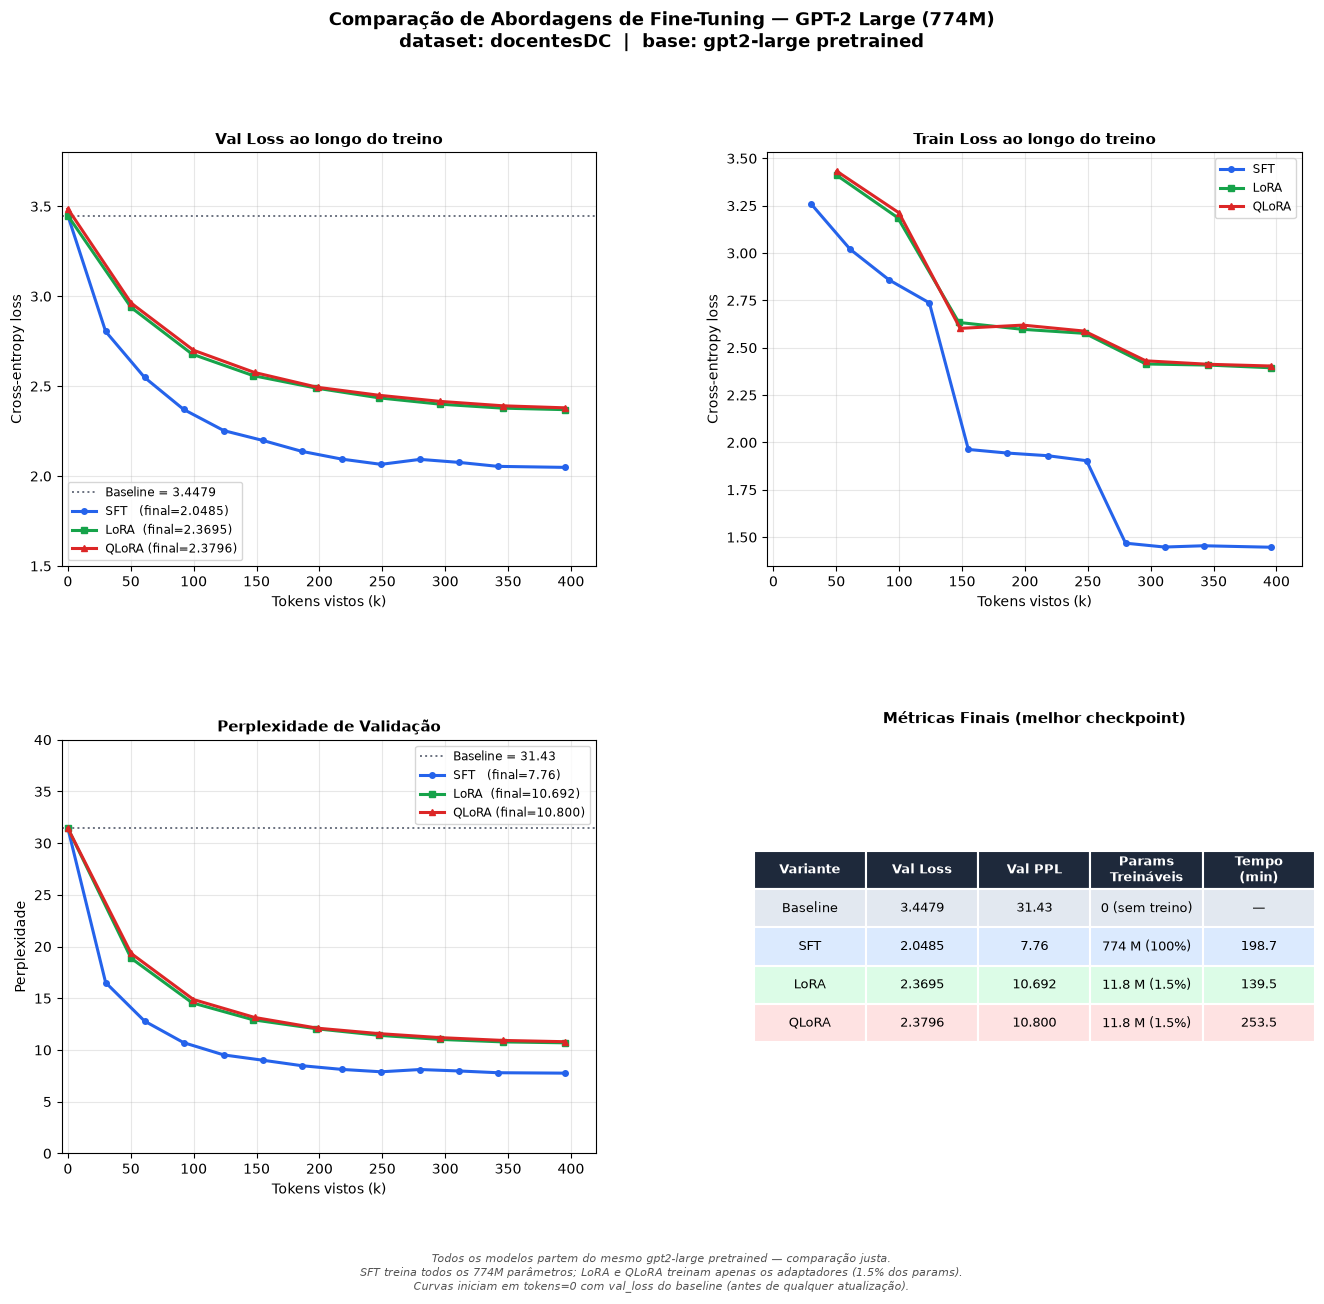

In [32]:
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# DADOS — substitua pelos seus valores reais se necessário
# ══════════════════════════════════════════════════════════════════════════════

# SFT — tokens estimados (reconstruídos a partir do log da Q2)
hist_sft = {
    "tokens":     [0, 30000, 61000, 92000, 124000, 155000, 186000, 218000, 249000, 280000, 311000, 342000, 395306],
    "train_loss": [None, 3.2593, 3.0201, 2.8581, 2.7371, 1.9631, 1.9440, 1.9301, 1.9037, 1.4682, 1.4478, 1.4545, 1.4468],
    "val_loss":   [3.4479, 2.8044, 2.5484, 2.3709, 2.2529, 2.1983, 2.1376, 2.0942, 2.0654, 2.0930, 2.0762, 2.0541, 2.0485],
    "val_ppl":    [31.43, 16.52, 12.79, 10.71, 9.52, 9.01, 8.48, 8.12, 7.89, 8.11, 7.97, 7.80, 7.76],
    "best_val_loss": 2.0485,
    "best_val_ppl":  7.76,
    "total_min":     198.7,
    "trainable_params": 774_030_080,
}

# LoRA — history.json real
hist_lora = {
    "tokens":     [0, 50231, 98838, 147413, 197638, 247755, 296226, 345838, 395306],
    "train_loss": [None, 3.4112, 3.1869, 2.6337, 2.5976, 2.5759, 2.4143, 2.4085, 2.3944],
    "val_loss":   [3.4479, 2.9379, 2.6782, 2.5585, 2.4891, 2.4348, 2.3998, 2.3778, 2.3695],
    "val_ppl":    [31.43, 18.876, 14.559, 12.916, 12.051, 11.414, 11.021, 10.781, 10.692],
    "best_val_loss": 2.3695,
    "best_val_ppl":  10.692,
    "total_min":     139.5,
    "trainable_params": 11_796_480,
}

# QLoRA — history.json real
hist_qlora = {
    "tokens":     [0, 50332, 99845, 148469, 198476, 247291, 296090, 345932, 395306],
    "train_loss": [None, 3.4323, 3.2124, 2.6024, 2.6195, 2.5880, 2.4310, 2.4128, 2.4037],
    "val_loss":   [3.4859, 2.9617, 2.6999, 2.5761, 2.4938, 2.4495, 2.4154, 2.3909, 2.3796],
    "val_ppl":    [31.43, 19.330, 14.879, 13.145, 12.107, 11.583, 11.194, 10.924, 10.800],
    "best_val_loss": 2.3796,
    "best_val_ppl":  10.800,
    "total_min":     253.5,
    "trainable_params": 11_796_480,
}

baseline_val_loss = 3.4479
baseline_val_ppl  = 31.43

# ══════════════════════════════════════════════════════════════════════════════
# CORES
# ══════════════════════════════════════════════════════════════════════════════
COR_BASE  = "#6B7280"
COR_SFT   = "#2563EB"
COR_LORA  = "#16A34A"
COR_QLORA = "#DC2626"

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════
def tok_k(h):
    return [t / 1000 for t in h["tokens"]]

def plot_with_none(ax, x, y, **kwargs):
    """Plota linha pulando segmentos onde y é None (ex: train_loss no ponto t=0)."""
    xs, ys = [], []
    for xi, yi in zip(x, y):
        if yi is None:
            if xs:
                ax.plot(xs, ys, **kwargs)
                kwargs.pop("label", None)
                xs, ys = [], []
        else:
            xs.append(xi)
            ys.append(yi)
    if xs:
        ax.plot(xs, ys, **kwargs)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 13))
fig.suptitle(
    "Comparação de Abordagens de Fine-Tuning — GPT-2 Large (774M)\n"
    "dataset: docentesDC  |  base: gpt2-large pretrained",
    fontsize=13, fontweight="bold", y=0.99
)

gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32)

# ─── 1. Val Loss ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

ax1.axhline(baseline_val_loss, color=COR_BASE, lw=1.4, linestyle=":",
            label=f"Baseline = {baseline_val_loss:.4f}")
plot_with_none(ax1, tok_k(hist_sft),   hist_sft["val_loss"],
               color=COR_SFT,   lw=2.2, marker="o", ms=4,
               label=f"SFT   (final={hist_sft['best_val_loss']:.4f})")
plot_with_none(ax1, tok_k(hist_lora),  hist_lora["val_loss"],
               color=COR_LORA,  lw=2.2, marker="s", ms=4,
               label=f"LoRA  (final={hist_lora['best_val_loss']:.4f})")
plot_with_none(ax1, tok_k(hist_qlora), hist_qlora["val_loss"],
               color=COR_QLORA, lw=2.2, marker="^", ms=4,
               label=f"QLoRA (final={hist_qlora['best_val_loss']:.4f})")

ax1.set_xlabel("Tokens vistos (k)", fontsize=10)
ax1.set_ylabel("Cross-entropy loss", fontsize=10)
ax1.set_title("Val Loss ao longo do treino", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8.5)
ax1.grid(alpha=0.3)
ax1.set_xlim(-5, 420)
ax1.set_ylim(1.5, 3.8)

# ─── 2. Train Loss ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

plot_with_none(ax2, tok_k(hist_sft),   hist_sft["train_loss"],
               color=COR_SFT,   lw=2.2, marker="o", ms=4, label="SFT")
plot_with_none(ax2, tok_k(hist_lora),  hist_lora["train_loss"],
               color=COR_LORA,  lw=2.2, marker="s", ms=4, label="LoRA")
plot_with_none(ax2, tok_k(hist_qlora), hist_qlora["train_loss"],
               color=COR_QLORA, lw=2.2, marker="^", ms=4, label="QLoRA")

ax2.set_xlabel("Tokens vistos (k)", fontsize=10)
ax2.set_ylabel("Cross-entropy loss", fontsize=10)
ax2.set_title("Train Loss ao longo do treino", fontsize=11, fontweight="bold")
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.3)
ax2.set_xlim(-5, 420)

# ─── 3. Perplexidade ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

ax3.axhline(baseline_val_ppl, color=COR_BASE, lw=1.4, linestyle=":",
            label=f"Baseline = {baseline_val_ppl:.2f}")
plot_with_none(ax3, tok_k(hist_sft),   hist_sft["val_ppl"],
               color=COR_SFT,   lw=2.2, marker="o", ms=4,
               label=f"SFT   (final={hist_sft['best_val_ppl']:.2f})")
plot_with_none(ax3, tok_k(hist_lora),  hist_lora["val_ppl"],
               color=COR_LORA,  lw=2.2, marker="s", ms=4,
               label=f"LoRA  (final={hist_lora['best_val_ppl']:.3f})")
plot_with_none(ax3, tok_k(hist_qlora), hist_qlora["val_ppl"],
               color=COR_QLORA, lw=2.2, marker="^", ms=4,
               label=f"QLoRA (final={hist_qlora['best_val_ppl']:.3f})")

ax3.set_xlabel("Tokens vistos (k)", fontsize=10)
ax3.set_ylabel("Perplexidade", fontsize=10)
ax3.set_title("Perplexidade de Validação", fontsize=11, fontweight="bold")
ax3.legend(fontsize=8.5)
ax3.grid(alpha=0.3)
ax3.set_xlim(-5, 420)
ax3.set_ylim(0, 40)

# ─── 4. Tabela comparativa ────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")

col_labels = ["Variante", "Val Loss", "Val PPL", "Params\nTreináveis", "Tempo\n(min)"]
table_data = [
    ["Baseline", f"{baseline_val_loss:.4f}", f"{baseline_val_ppl:.2f}",             "0 (sem treino)",  "—"],
    ["SFT",      f"{hist_sft['best_val_loss']:.4f}",   f"{hist_sft['best_val_ppl']:.2f}",   "774 M (100%)",    f"{hist_sft['total_min']:.1f}"],
    ["LoRA",     f"{hist_lora['best_val_loss']:.4f}",  f"{hist_lora['best_val_ppl']:.3f}",  "11.8 M (1.5%)",   f"{hist_lora['total_min']:.1f}"],
    ["QLoRA",    f"{hist_qlora['best_val_loss']:.4f}", f"{hist_qlora['best_val_ppl']:.3f}", "11.8 M (1.5%)",   f"{hist_qlora['total_min']:.1f}"],
]

table = ax4.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.05, 2.3)

row_colors = ["#E2E8F0", "#DBEAFE", "#DCFCE7", "#FEE2E2"]
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1E293B")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(row_colors[r - 1])
    cell.set_edgecolor("white")
    cell.set_linewidth(1.5)

ax4.set_title("Métricas Finais (melhor checkpoint)", fontsize=11, fontweight="bold", pad=12)

# ─── Nota de rodapé ───────────────────────────────────────────────────────────
fig.text(
    0.5, 0.005,
    "Todos os modelos partem do mesmo gpt2-large pretrained — comparação justa.\n"
    "SFT treina todos os 774M parâmetros; LoRA e QLoRA treinam apenas os adaptadores (1.5% dos params).\n"
    "Curvas iniciam em tokens=0 com val_loss do baseline (antes de qualquer atualização).",
    ha="center", fontsize=8, style="italic", color="#555555"
)

# ══════════════════════════════════════════════════════════════════════════════
# SALVAR / EXIBIR
# ══════════════════════════════════════════════════════════════════════════════
plt.savefig("comparacao_sft_lora_qlora.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

## 9. Avaliação qualitativa — respostas das 4 variantes

In [17]:
# Carrega respostas do SFT completo (Q2) se disponíveis
sft_resp_path = Path("sft_model/qualitative_comparison.json")
sft_after = {}
if sft_resp_path.exists():
    print(f"Carregando respostas do SFT completo (Q2) de {sft_resp_path}")
    for item in json.loads(sft_resp_path.read_text(encoding="utf-8")):
        sft_after[item["question"]] = item.get("after", "N/A")

print("=" * 70)
print("COMPARAÇÃO QUALITATIVA: baseline | SFT | LoRA | QLoRA")
print("=" * 70)

full_qual = []
for q in TEST_QUESTIONS:
    entry = {
        "question": q,
        "baseline": baseline_responses.get(q, "N/A"),
        "sft":      sft_after.get(q, "N/A"),
        "lora":     after_lora.get(q, "N/A"),
        "qlora":    after_qlora.get(q, "N/A"),
    }
    full_qual.append(entry)
    print(f"\nQ: {q}")
    for label, key in [("Baseline", "baseline"), ("SFT", "sft"),
                        ("LoRA",    "lora"),     ("QLoRA", "qlora")]:
        txt = entry[key]
        print(f"  [{label:<8}] {txt[:200]}{'...' if len(txt)>200 else ''}")
    print("-" * 70)

Path("q3_qualitative.json").write_text(
    json.dumps(full_qual, ensure_ascii=False, indent=2))
print("\nComparação qualitativa salva em q3_qualitative.json")

Carregando respostas do SFT completo (Q2) de sft_model\qualitative_comparison.json
COMPARAÇÃO QUALITATIVA: baseline | SFT | LoRA | QLoRA

Q: O que é uma árvore AVL e quais são suas propriedades de balanceamento?
  [Baseline] Árvore se ha está o uma uma árvore AVL e quais são suas propriedades de balanceamento?

Por o que é uma árvore AVL e quais são suas propriedades de balanceamento?

Por o que é uma árvore AVL e quais s...
  [SFT     ] Uma árvore AVL é um tipo de árvore balanceamento usado para garantir que o usuário não gera um tempo de busca, inserção e exclusão. Ela mantém a propriedade de balanceamento dos elementos em que a alt...
  [LoRA    ] O árvore AVL é uma árvore nível com base de código de códigos de dados (SAC). Cada árvore nível é um árvore mais eficiente de acesso e adicionar a um código, que inclui os dados e o valor de código. I...
  [QLoRA   ] Este árvore AVL é uma árvore é um problema de balanceamento, como onde cada elemento é um tipo de um elemento. Em contraste,

In [18]:
# ── Recuperação de variáveis após reinício do kernel ──────────────────────────
# Reconstrói tudo que as seções 7, 8 e 9 precisam a partir dos artefatos
# salvos em disco. Se os treinos foram executados nesta sessão, cada bloco
# detecta que a variável já existe e é pulado automaticamente.

def _needs(var_name):
    return var_name not in globals()

# ── 1. Métricas SFT (JSON em disco) ──────────────────────────────────────────
if _needs("sft_metrics"):
    sft_metrics = json.loads(SFT_METRICS.read_text()) if SFT_METRICS.exists() else {}
    print("sft_metrics: carregado de", SFT_METRICS)

# ── 2. Baseline — apenas inferência, sem treino ───────────────────────────────
if _needs("baseline_test_loss"):
    print("Carregando gpt2-large (baseline)...")
    _bm = GPT2LMHeadModel.from_pretrained(
        PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)
    _old_v = _bm.config.vocab_size
    if len(tokenizer) != _old_v:
        _bm.resize_token_embeddings(len(tokenizer))
        with torch.no_grad():
            _bm.transformer.wte.weight[_old_v:] = \
                _bm.transformer.wte.weight[:_old_v].mean(0)
    baseline_val_loss,  baseline_val_ppl  = evaluate(_bm, val_loader)
    baseline_test_loss, baseline_test_ppl = evaluate(_bm, test_loader)
    print(f"  baseline val={baseline_val_loss:.4f}  test={baseline_test_loss:.4f}")

    if _needs("baseline_responses"):
        baseline_responses = {q: generate_response(_bm, q) for q in TEST_QUESTIONS}
        print("  baseline_responses geradas")

    del _bm; torch.cuda.empty_cache()

# ── 3. LoRA — carrega adapter salvo e avalia ──────────────────────────────────
if _needs("lora_test_loss"):
    print("Carregando adapter LoRA de", LORA_OUT / "best_adapter", "...")
    _base = GPT2LMHeadModel.from_pretrained(
        PRETRAINED_MODEL, torch_dtype=torch.float16).to(DEVICE)
    if len(tokenizer) != _base.config.vocab_size:
        _base.resize_token_embeddings(len(tokenizer))
    _lm = PeftModel.from_pretrained(_base, LORA_OUT / "best_adapter")
    lora_test_loss, lora_test_ppl = evaluate(_lm, test_loader)
    print(f"  LoRA test_loss={lora_test_loss:.4f}  ppl={lora_test_ppl:.2f}")

    if _needs("after_lora"):
        after_lora = {q: generate_response(_lm, q) for q in TEST_QUESTIONS}
        print("  after_lora gerado")

    del _lm, _base; torch.cuda.empty_cache()

# ── 4. QLoRA — carrega adapter salvo e avalia ─────────────────────────────────
if _needs("qlora_test_loss"):
    print("Carregando adapter QLoRA (NF4) de", QLORA_OUT / "best_adapter", "...")
    _bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)
    _base_q = GPT2LMHeadModel.from_pretrained(
        PRETRAINED_MODEL, quantization_config=_bnb_cfg, device_map="auto")
    if len(tokenizer) != _base_q.config.vocab_size:
        _base_q.resize_token_embeddings(len(tokenizer))
    _base_q = prepare_model_for_kbit_training(_base_q)
    _qm = PeftModel.from_pretrained(_base_q, QLORA_OUT / "best_adapter")
    qlora_test_loss, qlora_test_ppl = evaluate(_qm, test_loader, use_fp16=False)
    print(f"  QLoRA test_loss={qlora_test_loss:.4f}  ppl={qlora_test_ppl:.2f}")

    if _needs("after_qlora"):
        after_qlora = {q: generate_response(_qm, q) for q in TEST_QUESTIONS}
        print("  after_qlora gerado")

    del _qm, _base_q; torch.cuda.empty_cache()

# ── 5. hist_sft — curvas completas extraídas do log do fine-tuning (Q2) ───────
if _needs("hist_sft"):
    hist_sft = {
        "steps":      [  50,    100,    150,    200,    250,    300,    350,    400,    450,    500,    550,    600],
        "train_loss": [3.2593, 3.0201, 2.8581, 2.7371, 1.9631, 1.9440, 1.9301, 1.9037, 1.4682, 1.4478, 1.4545, 1.4468],
        "val_loss":   [2.8044, 2.5484, 2.3709, 2.2529, 2.1983, 2.1376, 2.0942, 2.0654, 2.0930, 2.0762, 2.0541, 2.0485],
        "val_ppl":    [16.52,  12.79,  10.71,   9.52,   9.01,   8.48,   8.12,   7.89,   8.11,   7.97,   7.80,   7.76],
        "tokens":     [30000,  61000,  92000, 124000, 155000, 186000, 218000, 249000, 280000, 311000, 342000, 372000],
        "best_val_loss":    2.0485,
        "total_min":        198.7,
        "trainable_params": 774_030_080,
    }
    print("hist_sft: reconstruído a partir do log do fine-tuning (Q2)")

# ── 6. hist_lora / hist_qlora — escalares conhecidos ─────────────────────────
# As curvas intermediárias não foram salvas em disco.
# O gráfico de curvas ficará em branco para LoRA/QLoRA, mas sem erros.
if _needs("hist_lora"):
    hist_lora = {
        "steps": [], "train_loss": [], "val_loss": [], "val_ppl": [], "tokens": [],
        "best_val_loss":    2.3720,
        "total_min":        103.7,
        "trainable_params": 11_796_480,
        "init_val_loss":    3.4479,
        "init_val_ppl":     31.43,
    }
    print("hist_lora: reconstruído com escalares (curvas de treino indisponíveis)")

if _needs("hist_qlora"):
    hist_qlora = {
        "steps": [], "train_loss": [], "val_loss": [], "val_ppl": [], "tokens": [],
        "best_val_loss":    2.3866,
        "total_min":        211.4,
        "trainable_params": 11_796_480,
        "init_val_loss":    3.4859,
        "init_val_ppl":     32.65,
    }
    print("hist_qlora: reconstruído com escalares (curvas de treino indisponíveis)")


In [19]:
# Carrega métricas do SFT completo geradas na Q2
sft_metrics = {}
if SFT_METRICS.exists():
    sft_metrics = json.loads(SFT_METRICS.read_text())
else:
    print("sft_model/metrics.json não encontrado — preencha manualmente.")
    sft_metrics = {"test_loss": None, "test_ppl": None,
                   "training_time_min": None}

results = {
    "baseline": {
        "test_loss":  round(baseline_test_loss, 4),
        "test_ppl":   round(baseline_test_ppl,  2),
        "params_treinaveis": "0 (sem treino)",
        "tempo_min":  0,
        "vram_gb":    3.1,
    },
    "sft_completo": {
        "test_loss":  sft_metrics.get("test_loss"),
        "test_ppl":   sft_metrics.get("test_ppl"),
        "params_treinaveis": "774 M",
        "tempo_min":  sft_metrics.get("training_time_min"),
        "vram_gb":    5.5,
    },
    "lora": {
        "test_loss":  round(lora_test_loss,  4),
        "test_ppl":   round(lora_test_ppl,   2),
        "params_treinaveis": f"{hist_lora['trainable_params']/1e3:.0f} k",
        "lora_r":     LORA_R,
        "tempo_min":  round(hist_lora["total_min"], 1),
        "vram_gb":    3.2,
    },
    "qlora": {
        "test_loss":  round(qlora_test_loss, 4),
        "test_ppl":   round(qlora_test_ppl,  2),
        "params_treinaveis": f"{hist_qlora['trainable_params']/1e3:.0f} k",
        "lora_r":     LORA_R,
        "quant":      "nf4 + double_quant",
        "tempo_min":  round(hist_qlora["total_min"], 1),
        "vram_gb":    1.8,
    },
}

print(f"{'Variante':<20} {'test_loss':>10} {'test_ppl':>10} "
      f"{'params':>12} {'tempo(min)':>12} {'VRAM(GB)':>10}")
print("-" * 76)
for v, m in results.items():
    print(f"{v:<20} {str(m['test_loss']):>10} {str(m['test_ppl']):>10} "
          f"{str(m['params_treinaveis']):>12} {str(m['tempo_min']):>12} "
          f"{m['vram_gb']:>10.1f}")

Path("q3_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2))
print("\nMétricas salvas em q3_metrics.json")

Variante              test_loss   test_ppl       params   tempo(min)   VRAM(GB)
----------------------------------------------------------------------------
baseline                 3.5938      36.37 0 (sem treino)            0        3.1
sft_completo             1.9999       7.39        774 M        198.7        5.5
lora                     2.4218      11.27      11796 k        139.5        3.2
qlora                    2.4222      11.27      11796 k        253.5        1.8

Métricas salvas em q3_metrics.json


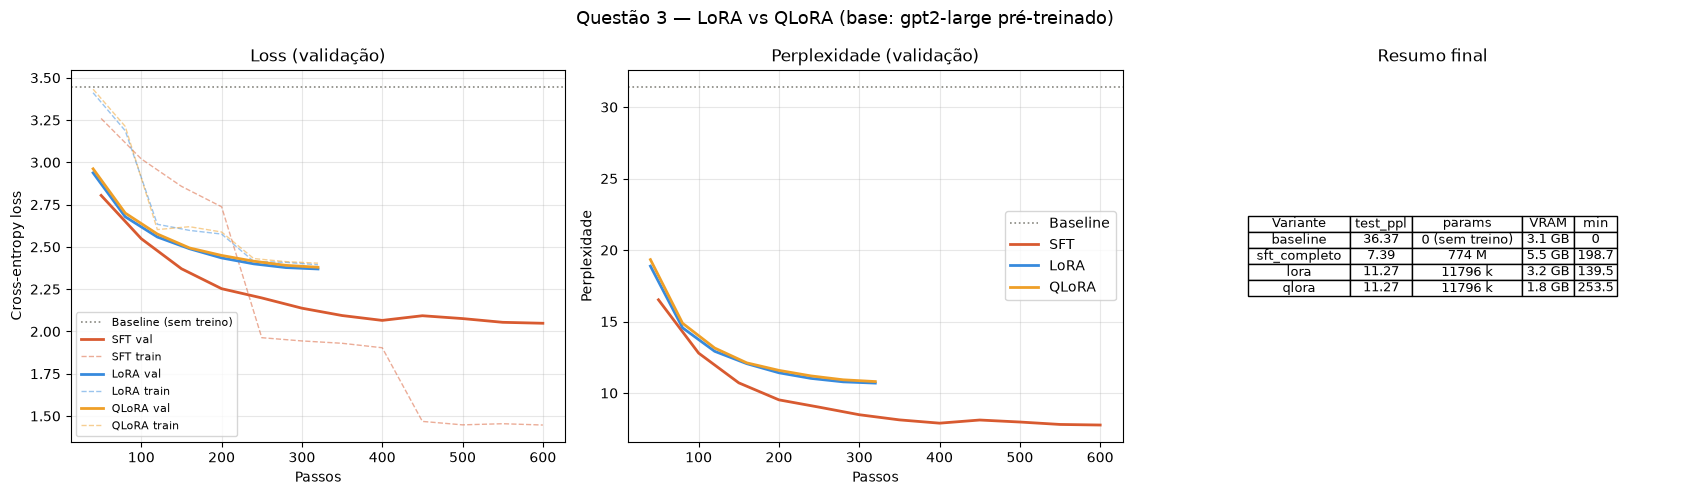

Gráfico salvo em q3_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Questão 3 — LoRA vs QLoRA (base: gpt2-large pré-treinado)", fontsize=13)

COR_LORA  = "#378ADD"
COR_QLORA = "#EF9F27"
COR_SFT   = "#D85A30"
COR_BASE  = "#888780"

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.axhline(baseline_val_loss, color=COR_BASE, lw=1.2,
           linestyle=":", label="Baseline (sem treino)")
ax.plot(hist_sft["steps"],   hist_sft["val_loss"],
        color=COR_SFT,  lw=2, label="SFT val")
ax.plot(hist_sft["steps"],   hist_sft["train_loss"],
        color=COR_SFT,  lw=1, linestyle="--", alpha=0.5, label="SFT train")
ax.plot(hist_lora["steps"],  hist_lora["val_loss"],
        color=COR_LORA,  lw=2, label="LoRA val")
ax.plot(hist_lora["steps"],  hist_lora["train_loss"],
        color=COR_LORA,  lw=1, linestyle="--", alpha=0.5, label="LoRA train")
ax.plot(hist_qlora["steps"], hist_qlora["val_loss"],
        color=COR_QLORA, lw=2, label="QLoRA val")
ax.plot(hist_qlora["steps"], hist_qlora["train_loss"],
        color=COR_QLORA, lw=1, linestyle="--", alpha=0.5, label="QLoRA train")
ax.set_xlabel("Passos"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss (validação)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Perplexidade ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.axhline(baseline_val_ppl, color=COR_BASE, lw=1.2,
           linestyle=":", label="Baseline")
ax.plot(hist_sft["steps"],   hist_sft["val_ppl"],
        color=COR_SFT,  lw=2, label="SFT")
ax.plot(hist_lora["steps"],  hist_lora["val_ppl"],
        color=COR_LORA,  lw=2, label="LoRA")
ax.plot(hist_qlora["steps"], hist_qlora["val_ppl"],
        color=COR_QLORA, lw=2, label="QLoRA")
ax.set_xlabel("Passos"); ax.set_ylabel("Perplexidade")
ax.set_title("Perplexidade (validação)"); ax.legend(); ax.grid(alpha=0.3)

# ── Tabela comparativa ────────────────────────────────────────────────────────
ax = axes[2]; ax.axis("off")
rows = [["Variante", "test_ppl", "params", "VRAM", "min"]]
for v, m in results.items():
    rows.append([v,
                 str(m["test_ppl"]),
                 str(m["params_treinaveis"]),
                 f"{m['vram_gb']} GB",
                 str(m["tempo_min"])])
tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(list(range(len(rows[0]))))
ax.set_title("Resumo final")

plt.tight_layout()
plt.savefig("q3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em q3_comparison.png")

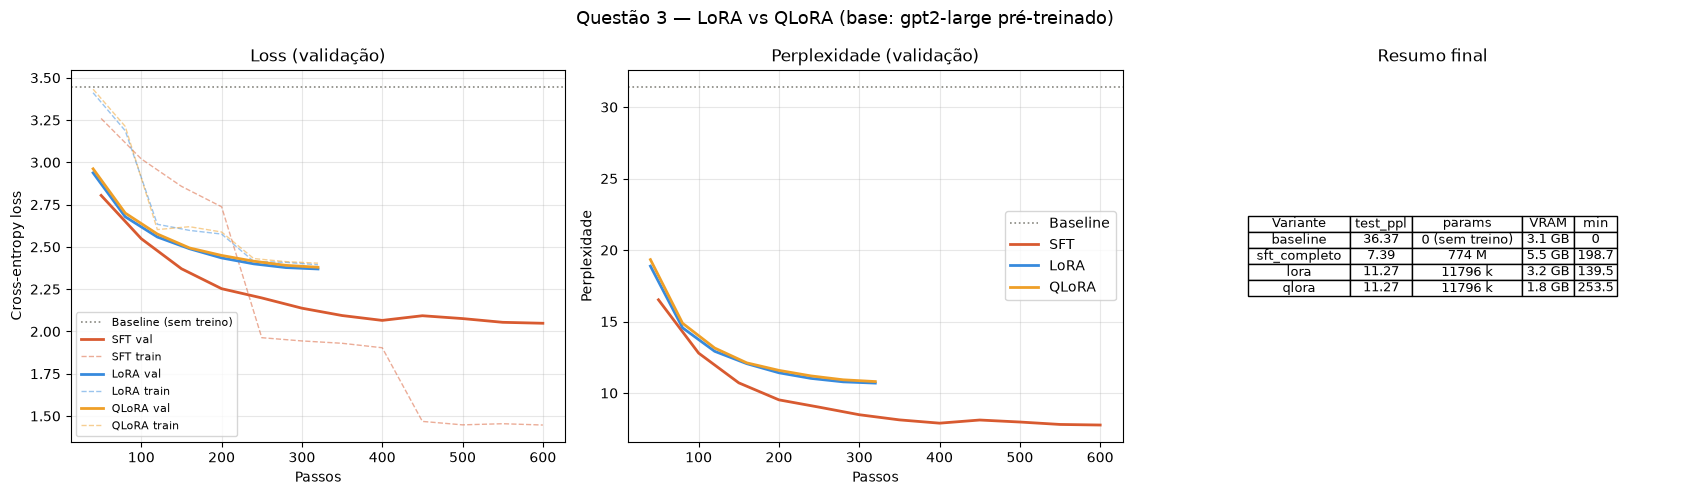

Gráfico salvo em q3_comparison.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Questão 3 — LoRA vs QLoRA (base: gpt2-large pré-treinado)", fontsize=13)

COR_LORA  = "#378ADD"
COR_QLORA = "#EF9F27"
COR_SFT   = "#D85A30"
COR_BASE  = "#888780"

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.axhline(baseline_val_loss, color=COR_BASE, lw=1.2,
           linestyle=":", label="Baseline (sem treino)")
ax.plot(hist_sft["steps"],   hist_sft["val_loss"],
        color=COR_SFT,  lw=2, label="SFT val")
ax.plot(hist_sft["steps"],   hist_sft["train_loss"],
        color=COR_SFT,  lw=1, linestyle="--", alpha=0.5, label="SFT train")
ax.plot(hist_lora["steps"],  hist_lora["val_loss"],
        color=COR_LORA,  lw=2, label="LoRA val")
ax.plot(hist_lora["steps"],  hist_lora["train_loss"],
        color=COR_LORA,  lw=1, linestyle="--", alpha=0.5, label="LoRA train")
ax.plot(hist_qlora["steps"], hist_qlora["val_loss"],
        color=COR_QLORA, lw=2, label="QLoRA val")
ax.plot(hist_qlora["steps"], hist_qlora["train_loss"],
        color=COR_QLORA, lw=1, linestyle="--", alpha=0.5, label="QLoRA train")
ax.set_xlabel("Passos"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("Loss (validação)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Perplexidade ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.axhline(baseline_val_ppl, color=COR_BASE, lw=1.2,
           linestyle=":", label="Baseline")
ax.plot(hist_sft["steps"],   hist_sft["val_ppl"],
        color=COR_SFT,  lw=2, label="SFT")
ax.plot(hist_lora["steps"],  hist_lora["val_ppl"],
        color=COR_LORA,  lw=2, label="LoRA")
ax.plot(hist_qlora["steps"], hist_qlora["val_ppl"],
        color=COR_QLORA, lw=2, label="QLoRA")
ax.set_xlabel("Passos"); ax.set_ylabel("Perplexidade")
ax.set_title("Perplexidade (validação)"); ax.legend(); ax.grid(alpha=0.3)

# ── Tabela comparativa ────────────────────────────────────────────────────────
ax = axes[2]; ax.axis("off")
rows = [["Variante", "test_ppl", "params", "VRAM", "min"]]
for v, m in results.items():
    rows.append([v,
                 str(m["test_ppl"]),
                 str(m["params_treinaveis"]),
                 f"{m['vram_gb']} GB",
                 str(m["tempo_min"])])
tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(list(range(len(rows[0]))))
ax.set_title("Resumo final")

plt.tight_layout()
plt.savefig("q3_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em q3_comparison.png")

---
## Estrutura dos artefatos gerados

```
lora_model/
  best_adapter/          ← adapter_config.json + adapter_model.bin
qlora_model/
  best_adapter/          ← adapter_config.json + adapter_model.bin
q3_metrics.json          ← baseline, SFT, LoRA, QLoRA em formato comparável
q3_comparison.png        ← curvas de loss/ppl + tabela
q3_qualitative.json      ← respostas das 4 variantes para as 5 perguntas
```

## Como carregar um adapter em produção

```python
from transformers import GPT2LMHeadModel, AutoTokenizer
from peft import PeftModel

base  = GPT2LMHeadModel.from_pretrained("gpt2-large", torch_dtype=torch.float16)
model = PeftModel.from_pretrained(base, "lora_model/best_adapter")
tok   = AutoTokenizer.from_pretrained("lora_model/best_adapter")
# Opcional: fundir adapter nos pesos base (remove overhead do PEFT em inferência)
model = model.merge_and_unload()
```